# 03 — Comparação de modelos e explicabilidade SHAP

Compara **Regressão Logística (baseline)**, **Random Forest** e **XGBoost ajustado** no mesmo conjunto temporal de validação (88.581 transações). Em seguida, apresenta a importância global e quatro explicações locais do XGBoost.

> O IEEE-CIS representa comércio eletrônico/cartão, não Pix real. SHAP descreve influência sobre o modelo; não demonstra causalidade, culpa ou intenção.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

RAIZ = Path.cwd()
if not (RAIZ / 'reports').is_dir():
    RAIZ = RAIZ.parent

def carregar_json(caminho):
    return json.loads(caminho.read_text(encoding='utf-8'))

xgb = carregar_json(RAIZ / 'reports' / 'tuning_xgboost.json')
rf = carregar_json(RAIZ / 'reports' / 'random_forest.json')
shap_resultado = carregar_json(
    RAIZ / 'reports' / 'pessoa_1' / 'julho' / 'shap' / 'shap_xgboost.json'
)
print('Relatórios carregados com sucesso.')

Relatórios carregados com sucesso.


## Comparação na validação

A comparação principal usa **AUC-PR**, adequada à classe rara e independente de limiar. Precisão, recall e F1 abaixo usam o limiar 0,5 e devem ser lidos como pontos operacionais, não como ranking absoluto entre modelos.

In [2]:
baseline = xgb['baseline_junho_validacao'].copy()
baseline['f1'] = 2 * baseline['precisao'] * baseline['recall'] / (baseline['precisao'] + baseline['recall'])
floresta = rf['arvores_completas']
xg_final = xgb['metricas_modelo_final_validacao']

linhas = {
    'Regressão Logística (baseline)': baseline,
    'Random Forest (árvores completas)': floresta,
    'XGBoost ajustado (Optuna)': xg_final,
}
colunas = {'auc_pr': 'AUC-PR', 'auc_roc': 'AUC-ROC', 'recall': 'Recall', 'precisao': 'Precisão', 'f1': 'F1'}
comparacao = pd.DataFrame(linhas).T[list(colunas)].rename(columns=colunas)
display(comparacao.round(4))

,AUC-PR,AUC-ROC,Recall,Precisão,F1
Regressão Logística (baseline),0.393,0.841,0.6772,0.135,0.225122
Random Forest (árvores completas),0.529772,0.907767,0.319198,0.801817,0.456619
XGBoost ajustado (Optuna),0.57032,0.907007,0.56213,0.519757,0.540114


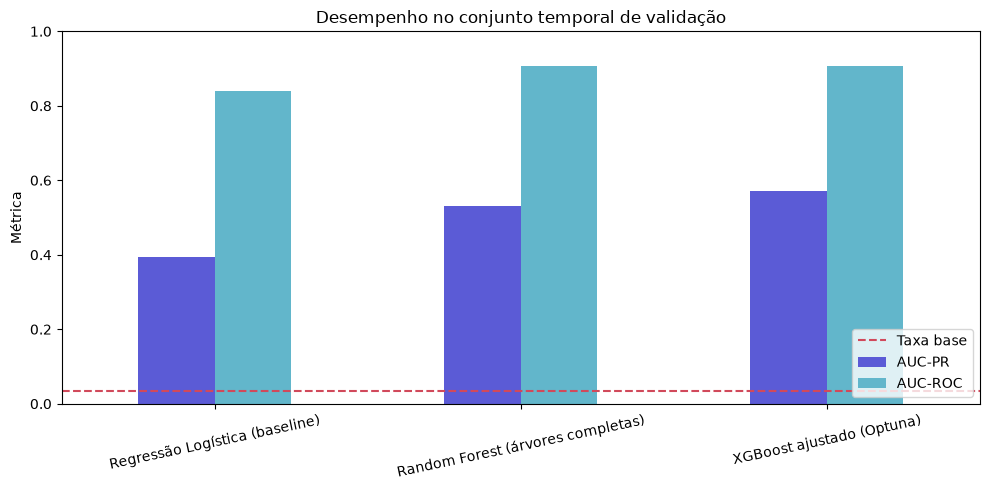

In [3]:
ax = comparacao[['AUC-PR', 'AUC-ROC']].plot.bar(
    figsize=(10, 5), color=['#5b5bd6', '#62b6cb'], rot=12
)
ax.axhline(xgb['metricas_modelo_final_validacao']['taxa_base'], color='#d1495b', linestyle='--', label='Taxa base')
ax.set_ylim(0, 1)
ax.set_ylabel('Métrica')
ax.set_title('Desempenho no conjunto temporal de validação')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Leitura dos resultados

- O XGBoost ajustado obteve **AUC-PR 0,5703**, contra **0,5298** do Random Forest e **0,3930** do baseline.
- A vantagem sobre a floresta é de 0,0405 de AUC-PR. A comparação é assimétrica: o XGBoost passou por ajuste com Optuna; o Random Forest é apenas o comparador previsto na proposta.
- No limiar 0,5, o Random Forest privilegia precisão (0,8018) e o XGBoost recupera mais fraudes (recall 0,5621). Isso descreve calibração/ponto de operação, não superioridade geral.
- O conjunto de teste permanece reservado para a avaliação final, depois da escolha formal do limiar.

## SHAP — importância global

O `TreeExplainer` foi executado com `feature_perturbation='interventional'`, fundo de 500 linhas retiradas somente do treino e saída em escala de probabilidade. O gráfico usa 1.000 transações aleatórias da validação.

In [4]:
top_shap = pd.DataFrame(shap_resultado['importancia_global']).head(15)
top_shap.rename(columns={
    'posicao': 'Posição',
    'feature': 'Feature',
    'media_shap_absoluto': 'Média |SHAP|',
}).round({'Média |SHAP|': 6})

,Posição,Feature,Média |SHAP|
0,1,TransactionAmt,0.016792
1,2,C13,0.014698
2,3,C1,0.010494
3,4,C14,0.008528
4,5,card1,0.008383
5,6,C5,0.007558
6,7,valor_atipico_proxy,0.006856
7,8,card2,0.006801
8,9,D1,0.006671
9,10,P_emaildomain,0.006519


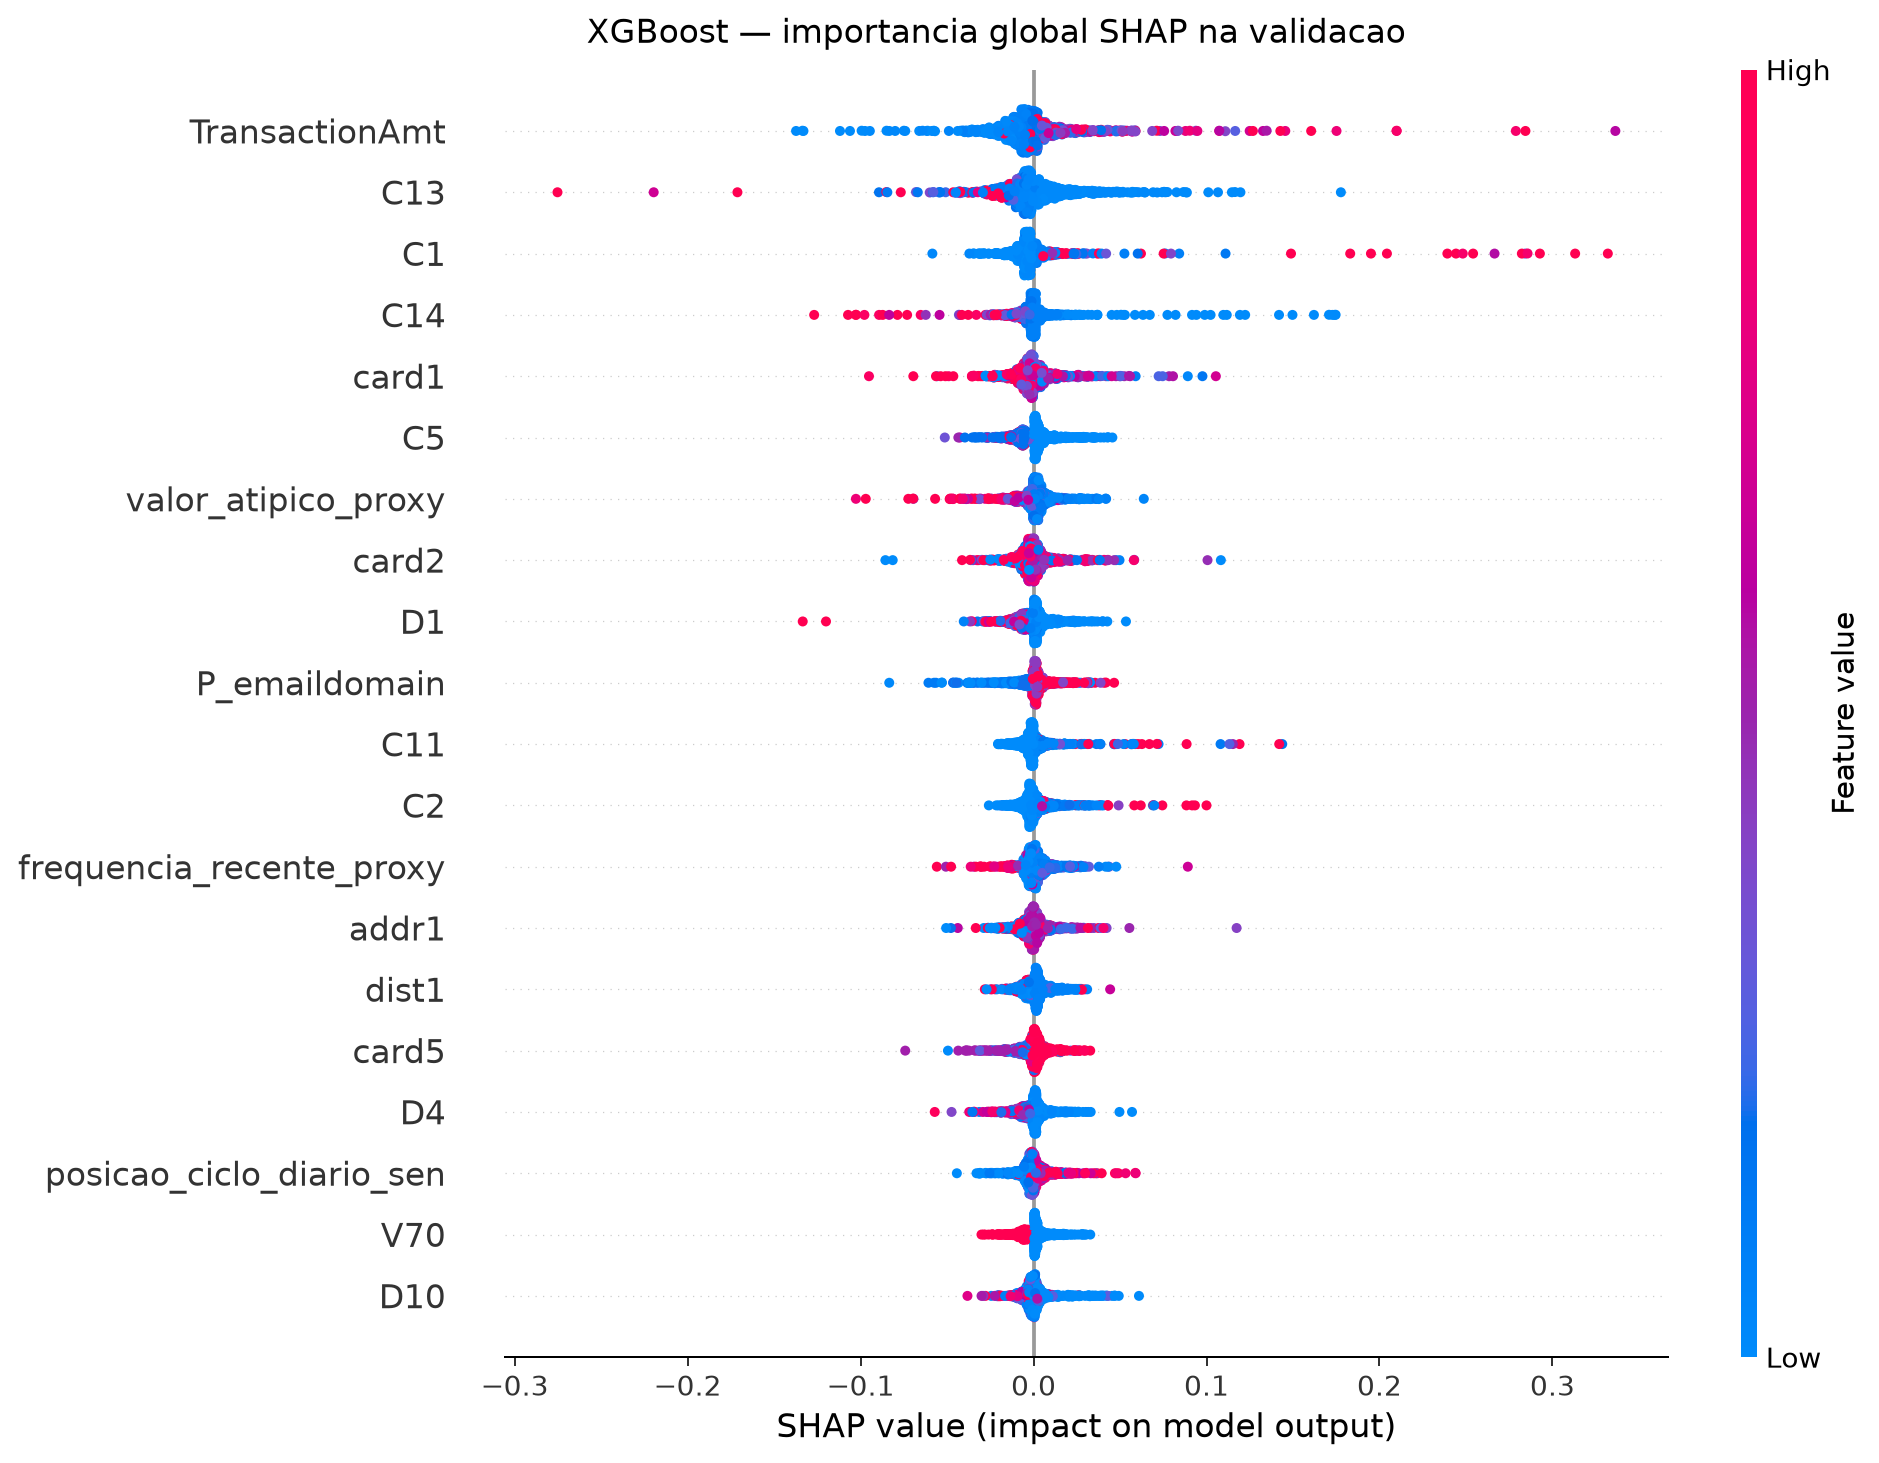

In [5]:
caminho_summary = RAIZ / 'reports' / 'pessoa_1' / 'julho' / 'shap' / shap_resultado['artefatos']['summary_plot']
display(Image(filename=str(caminho_summary), width=950))

## SHAP — explicações por transação

Foi selecionado o caso mais próximo da probabilidade mediana em cada quadrante: verdadeiro positivo, falso positivo, falso negativo e verdadeiro negativo. Os *force plots* completos estão em `reports/pessoa_1/julho/shap/` nos formatos PNG e HTML.

In [6]:
casos = pd.DataFrame([{
    'Caso': caso['tipo'].replace('_', ' ').title(),
    'Classe real': caso['classe_real'],
    'Classe predita': caso['classe_predita'],
    'Probabilidade de fraude': caso['probabilidade_fraude'],
    'Principal contribuição': caso['principais_contribuicoes'][0]['feature'],
    'SHAP principal': caso['principais_contribuicoes'][0]['shap'],
} for caso in shap_resultado['casos_locais']])
display(casos.round({'Probabilidade de fraude': 4, 'SHAP principal': 4}))

,Caso,Classe real,Classe predita,Probabilidade de fraude,Principal contribuição,SHAP principal
0,Verdadeiro Positivo,1,1,0.9624,C14,0.1683
1,Falso Positivo,0,1,0.6692,card1,0.0793
2,Falso Negativo,1,0,0.1210,TransactionAmt,0.0898
3,Verdadeiro Negativo,0,0,0.0098,posicao_ciclo_diario_sen,-0.0123


In [7]:
fidelidade = shap_resultado['fidelidade']
print(f"Fidelidade aditiva: {'APROVADA' if fidelidade['aprovada'] else 'REPROVADA'}")
print(f"Erro máximo: {fidelidade['erro_maximo']:.3e} (tolerância {fidelidade['tolerancia']:.1e})")
print(f"Versões: XGBoost {shap_resultado['versoes']['xgboost']} | SHAP {shap_resultado['versoes']['shap']}")

Fidelidade aditiva: APROVADA
Erro máximo: 3.039e-07 (tolerância 1.0e-05)
Versões: XGBoost 3.0.5 | SHAP 0.52.0


## Conclusão e limites

O **XGBoost ajustado** é o modelo escolhido para a próxima camada por apresentar a maior AUC-PR na validação. `TransactionAmt`, `C13`, `C1`, `C14` e `card1` lideraram a importância global; entre as proxies documentadas, `valor_atipico_proxy` ficou em 7º lugar e `frequencia_recente_proxy` em 13º.

As contribuições SHAP são fiéis à probabilidade do modelo dentro da tolerância numérica, mas não transformam atributos anônimos em conceitos Pix e não validam a correção da classificação. A avaliação final no teste e a escolha do limiar são etapas separadas.